# From CHAP envelopes to decisions

> The record of a collaboration between people and agents, measured and drawn.

A CHAP coordinator keeps an audit log of everything humans and agents did
together in a workspace: every task created, every draft submitted, every
approval, correction, question, handoff and vote. Each entry is a JSON-RPC
envelope, and where the coordinator chains its log each entry is hash-linked
to the one before it.

`chap-analytics` reads that log back. This notebook follows one week of work
through the whole pipeline: the raw envelopes as `audit.read` returns them; a
`Chain`, which is the package's view of a workspace; `frames()`, which replays
the chain into eleven tables; the contract each table keeps; the tables
themselves; the analyses they make routine; what an MCP client with
`audit.read` alone can recover, and how the tables say where they are unsure;
redaction; and export. It then goes on to the decision layer: the statistics
with their intervals, the charts, the chain as a graph, the standalone report,
and the exports and models, on the week and on a generated quarter.

Everything below runs against a real coordinator. The week is generated by
`chap_analytics.sample`, so the numbers reflect the coordinator that is
installed and are the same for the same seed.

## Setup

`pandas` and `numpy` are the package's dependencies. Generating the sample
week drives a coordinator in this process, which needs `chap-coordinator` as
well, and the charts below carry an SVG rendering where `vl-convert` is
installed:

```bash
pip install 'chap-analytics[coordinator,viz]'
```

In [1]:
import json
import pandas as pd

from chap_analytics import Chain, frames, from_coordinator, describe, redact_artefacts
from chap_analytics.sample import WORKSPACE, support_desk_coordinator

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

coord = support_desk_coordinator(seed=7)

## 1. The envelopes

`audit.read` is a CHAP method like any other, and it is what an MCP client can
call to get the log. Each entry carries its position in the log (`seq`), when
the coordinator accepted it (`arrived`), the hash link to the previous entry
(`prev_hash`, present because this coordinator chains its log), and the
envelope itself: the method, and the request parameters exactly as the caller
sent them.

The sample coordinator runs a deterministic clock, so `arrived` is an
artificial timeline. The sender stamps its own `ts` into every envelope, and
that carries the week.

In [2]:
result = coord.dispatch({
    "jsonrpc": "2.0", "id": "read", "method": "audit.read",
    "params": {"workspace": WORKSPACE, "from": "human:maya"},
})
entries = result["result"]["entries"]
print(f"{len(entries)} entries in the log")
pd.Series([e["envelope"]["method"] for e in entries]).value_counts().rename("count").to_frame()

169 entries in the log


,count
task.complete,41
task.create,38
review.request,38
decide.approve,19
decide.override,11
participant.join,5
decide.reject,3
deliberate.vote,3
whisper.ask,2
workspace.create,1


Three entries show the shape. A `task.create` names the work, who is to do it,
and the routing hints it arrived with. A `review.request` carries the artefact
under review. A `decide.override` carries the RFC 6902 patch the reviewer
applied, their rationale, and the tags and policy references they attached.

Server-minted identifiers, such as the id of a task, are returned to the caller
in the *result* of the call. The audit log records the envelopes, so a task's
id becomes visible in the log when a later envelope acts on it. That detail
matters later.

In [3]:
def first(method):
    return next(e for e in entries if e["envelope"]["method"] == method)

for method in ("task.create", "review.request", "decide.override"):
    entry = first(method)
    print(f"seq {entry['seq']}  arrived {entry['arrived']}  prev_hash {entry.get('prev_hash')}")
    print(json.dumps(entry["envelope"]["params"], indent=1), "\n")

seq 6  arrived 2026-03-02T09:47:54.876Z  prev_hash sha256:553d74ebd06204fcd6e7ecaddf72f72f401db399514aaf4504c7db84990e0e9d
{
 "workspace": "wsp_support",
 "from": "service:intake",
 "ts": "2026-03-02T09:47:54.000Z",
 "kind": "draft_reply",
 "assignee": "agent:drafter",
 "routing_hints": {
  "confidence": "0.88",
  "criticality": "low"
 },
 "input": {
  "ticket": "T-1041",
  "category": "account",
  "refund_requested": 0
 }
} 

seq 8  arrived 2026-03-02T09:49:07.915Z  prev_hash sha256:148492cde4cd1c9578582d6f40865d5ec4164df1f4c8208926ed8384c19f8838
{
 "workspace": "wsp_support",
 "from": "agent:drafter",
 "ts": "2026-03-02T09:49:07.000Z",
 "task_id": "tsk_01M2ZN8PKWCAQBGSAY2BPZ6Z20",
 "artefact": {
  "reply": "Hello, about your account request on T-1041: ...",
  "refund_amount": 0
 },
 "to": [
  "human:priya"
 ],
 "rule": "any_one_approves"
} 

seq 24  arrived 2026-03-02T18:38:28.141Z  prev_hash sha256:a53bb88ddb355901d63feffa4ad51f6b5bf67b76186bb4528ddab77477fddc87
{
 "workspace": "wsp

## 2. A `Chain`

A `Chain` is one workspace's history, ready to project: the envelope stream,
plus whatever server state the source carried. The four loaders return one:

```python
from chap_analytics import from_sqlite, from_url, from_json, from_coordinator

from_sqlite("./chap.db", workspace="wsp_support")     # the coordinator's SQLite file
from_url("http://localhost:8080/chap", "wsp_support") # a running coordinator, via audit.read
from_json("export.json")                              # an audit.read result, a bare entry list, or a snapshot
from_coordinator(coord, workspace="wsp_support")      # a Coordinator object in this process
```

A SQLite file or a live coordinator carries the workspace snapshot beside the
log; `audit.read` carries the log. `chain.has_state` says which you have, and
the tables say what that changes. Both are built here so the two reads can be
compared at the end. There is no HTTP server in this notebook, so the
envelope-only chain is built directly from the `audit.read` result;
`support_desk(envelopes_only=True)` does the same in one call.

In [4]:
with_state = from_coordinator(coord, workspace=WORKSPACE)
envelopes_only = Chain(workspace=WORKSPACE, events=entries, state=None, source="audit.read")

print(with_state)
print(envelopes_only)
print()
print(with_state.summary())

<Chain 'wsp_support' 169 events, with state, from coordinator>
<Chain 'wsp_support' 169 events, envelopes only, from audit.read>

<Chain 'wsp_support' 169 events, with state, from coordinator>
     41  task.complete
     38  review.request
     38  task.create
     19  decide.approve
     11  decide.override
      5  participant.join
      3  decide.reject
      3  deliberate.vote
      2  whisper.ask
      1  abstain.declare
      1  deliberate.close
      1  deliberate.open
      1  escalate.raise
      1  handoff.accept
      1  handoff.propose
      1  notify.message
      1  whisper.answer
      1  workspace.create


## 3. `frames()`

`frames(chain)` replays the envelope stream once into an index of what
happened, then builds every table as a view over that index. Replaying the
envelopes is what lets the whole layer work from `audit.read` alone: the
artefact under review arrives on `review.request` and the patch on
`decide.override`, so the before and the after of every correction are in the
log. The snapshot adds what the server computed: deliberation and routing
outcomes.

In [5]:
f = frames(with_state)
print(f.summary())

<Chain 'wsp_support' 169 events, with state, from coordinator>

  events            169 rows   one row per audit log entry
  tasks              39 rows   one row per task
  decisions          34 rows   one row per review decision
  overrides          11 rows   one row per override
  patch_ops          11 rows   one row per RFC 6902 operation within an override
  participants        5 rows   one row per participant per workspace
  deliberations       1 rows   one row per deliberation
  votes               3 rows   one row per vote in a deliberation
  whispers            2 rows   one row per whisper
  handoffs            1 rows   one row per proposed handoff
  routing             0 rows   one row per routing decision


## 4. The contract

Every column is declared in `schema.py` with its dtype and its provenance, and
`frames()` enforces the declaration: every table has exactly those columns, in
that order, with those dtypes. A column the source lacked a value for is
present and null, so downstream code can reference any column whatever the
chain came from.

Provenance has four values:

| Provenance | Meaning |
|---|---|
| `envelopes` | Read straight from a request parameter. |
| `state` | Computed by the server and carried in the snapshot. Null from `audit.read` alone. |
| `replay` | Derived by replaying the envelope stream. Available from either source. |
| `derived` | Computed from the other columns: counts, durations, flags, labels. |

`describe()` prints the whole contract; `print(describe())` shows every table.
The `tasks` block is shown here.

In [6]:
blocks = describe().split("\n\n")
print(next(b for b in blocks if b.startswith("tasks")))

tasks  (one row per task)
  A task and how it ended. The lifecycle columns are derived by replaying state transitions, so they hold for a chain read from envelopes alone.
    task_id            string                   [envelopes]  Task id.
    workspace          string                   [envelopes]  Workspace id.
    kind               string                   [envelopes]  Operator-defined task kind, uninterpreted by the coordinator.
    delegator          string                   [envelopes]  Who created the task.
    assignee           string                   [replay]  Current assignee, after any handoff. A task.route reassignment names its choice in the result rather than the envelope, so it is reflected where the source carried server state; see assignee_certain.
    assignee_certain   boolean                  [derived]  Whether assignee is known to be current. False where a task.route ran and the source could only say who held the task before it. Also false where the assignee wa

## 5. The tables

Each table has one grain, stated in `schema.py`. The sections below show the
first rows and the dtypes of each, and the columns worth knowing.

### `events`: one row per audit log entry

The chain itself, flattened. Every other table is a projection of this one, so
every count elsewhere reconciles with a count here. `ts` is the sender's
timestamp and `arrived` is the coordinator's; `actor_kind` is the URI scheme of
whoever made the call.

In [7]:
f.events.head(8)

,seq,workspace,ts,arrived,method,actor,actor_kind,task_id,prev_hash,chained,signed,scitt_submitted
0,0,wsp_support,2026-03-02 09:00:00+00:00,2026-03-02 09:00:00+00:00,workspace.create,service:intake,service,<NA>,sha256:000000000000000000000000000000000000000...,True,False,False
1,1,wsp_support,2026-03-02 09:00:00+00:00,2026-03-02 09:00:00+00:00,participant.join,service:intake,service,<NA>,sha256:9566d50d157cac0d0d42954bfa78d44eb52d0e8...,True,False,False
2,2,wsp_support,2026-03-02 09:00:00+00:00,2026-03-02 09:00:00+00:00,participant.join,agent:drafter,agent,<NA>,sha256:7bd3c13ecf373934c80c20d32558607b728b10f...,True,False,False
3,3,wsp_support,2026-03-02 09:00:00+00:00,2026-03-02 09:00:00+00:00,participant.join,human:maya,human,<NA>,sha256:508679b198b9b16c6eb26d28ec5bdb3699056d3...,True,False,False
4,4,wsp_support,2026-03-02 09:00:00+00:00,2026-03-02 09:00:00+00:00,participant.join,human:sam,human,<NA>,sha256:415016928d43a58556c08ffdb1825c6c73367ec...,True,False,False
5,5,wsp_support,2026-03-02 09:00:00+00:00,2026-03-02 09:00:00+00:00,participant.join,human:priya,human,<NA>,sha256:5c437197fb54754ee003eff804b254ad75d3741...,True,False,False
6,6,wsp_support,2026-03-02 09:47:54+00:00,2026-03-02 09:47:54.876000+00:00,task.create,service:intake,service,<NA>,sha256:553d74ebd06204fcd6e7ecaddf72f72f401db39...,True,False,False
7,7,wsp_support,2026-03-02 09:49:07+00:00,2026-03-02 09:49:07.915000+00:00,task.complete,agent:drafter,agent,tsk_01M2ZN8PKWCAQBGSAY2BPZ6Z20,sha256:35cd954b0f1d106e44474dfb891e1446eb407a1...,True,False,False


In [8]:
f.events.dtypes.to_frame("dtype")

,dtype
seq,Int64
workspace,string[python]
ts,"datetime64[ns, UTC]"
arrived,"datetime64[ns, UTC]"
method,string[python]
actor,string[python]
actor_kind,string[python]
task_id,string[python]
prev_hash,string[python]
chained,boolean


### `tasks`: one row per task

A task and how it ended. The lifecycle columns are replayed from state
transitions, so they hold from envelopes alone.

- `outcome` says how the task ended. Where a review settled it, the value is
  read from the decision that settled the last pass: `approved`, `overridden`,
  `rejected` or `abstained`. Otherwise it is the state the task reached:
  `escalated`, `cancelled`, `superseded`, `declined`,
  `completed_after_rejection`, `completed_bypassing_review`,
  `completed_without_review` or `open`.
- `settled` and `lifetime_s` censor open work: a task still running when the
  chain was read has a null lifetime, and the flag says so.
- `n_reviews` counts review passes. A task sent back for revision is reviewed
  again, and each pass judged its own artefact.
- `confidence` is the agent's self-reported confidence, parsed from its
  decimal-string wire form into a float.
- `id_certain` and `assignee_certain` say how sure the projection is about the
  row; section 7 explains them.

In [9]:
f.tasks[["task_id", "kind", "assignee", "state", "outcome", "settled", "lifetime_s",
         "n_reviews", "n_decisions", "confidence", "criticality", "id_certain"]].head(10)

,task_id,kind,assignee,state,outcome,settled,lifetime_s,n_reviews,n_decisions,confidence,criticality,id_certain
0,tsk_01M2ZN8PKWCAQBGSAY2BPZ6Z20,draft_reply,agent:drafter,completed,approved,True,5419.0,1,1,0.88,low,True
1,tsk_01M2ZN8PKWCTQ9QNWDZAW8PD2X,draft_reply,agent:drafter,completed,approved,True,5270.0,1,1,0.72,low,True
2,tsk_01M2ZN8PKW764CZA6K8KJPF6CG,draft_reply,agent:drafter,completed,approved,True,9377.0,2,2,0.86,low,True
3,tsk_01M2ZN8PKW657FV2NZKNXG55WX,draft_reply,agent:drafter,completed,overridden,True,5201.0,1,1,0.73,low,True
4,tsk_01M2ZN8PKXVQC5P2YKETGPXX05,draft_reply,agent:drafter,completed,approved,True,8467.0,1,1,0.88,low,True
5,tsk_01M2ZN8PKXVM9AH9Q4050F71Z3,draft_reply,agent:drafter,completed,overridden,True,355350.0,1,1,0.72,low,True
6,tsk_01M2ZN8PKX6MJ6YV1AYB9WTTF9,draft_reply,agent:drafter,completed,approved,True,836.0,1,1,0.78,low,True
7,tsk_01M2ZN8PKX2GRQWTRACX69JH3Z,draft_reply,agent:drafter,completed,approved,True,322314.0,1,1,0.74,low,True
8,tsk_01M2ZN8PKY65DBBV8N3SWYXCZW,draft_reply,agent:drafter,completed,approved,True,4360.0,1,1,0.79,low,True
9,tsk_01M2ZN8PKYJNJX02TNKG4PFBJQ,draft_reply,agent:drafter,review_requested,open,False,NaN,1,0,0.90,low,True


In [10]:
f.tasks.dtypes.to_frame("dtype")

,dtype
task_id,string[python]
workspace,string[python]
kind,string[python]
delegator,string[python]
assignee,string[python]
assignee_certain,boolean
id_certain,boolean
original_assignee,string[python]
mode,string[python]
review_required,boolean


### `decisions`: one row per approve, reject, override or abstain

The unit of analysis for anything about reviewers. `review_index` says which
pass on the task a decision belongs to, `is_final` whether it settled that
pass, and `latency_s` is measured from the opening of the decision's own pass.
`is_final` is computed with the coordinator's own rule: under `quorum:2` the
second approval settles the review, and under `all_approve` the last named
reviewer does.

In [11]:
f.decisions[["task_id", "reviewer", "kind", "rule", "review_index", "decision_index",
             "is_final", "latency_s", "request_revision", "tags"]].head(10)

,task_id,reviewer,kind,rule,review_index,decision_index,is_final,latency_s,request_revision,tags
0,tsk_01M2ZN8PKWCAQBGSAY2BPZ6Z20,human:priya,approve,any_one_approves,0,0,True,5346.0,<NA>,[]
1,tsk_01M2ZN8PKWCTQ9QNWDZAW8PD2X,human:sam,approve,any_one_approves,0,0,True,5194.0,<NA>,[]
2,tsk_01M2ZN8PKW764CZA6K8KJPF6CG,human:maya,reject,any_one_approves,0,0,False,7760.0,True,[]
3,tsk_01M2ZN8PKW764CZA6K8KJPF6CG,human:maya,approve,any_one_approves,1,0,True,688.0,<NA>,[]
4,tsk_01M2ZN8PKW657FV2NZKNXG55WX,human:maya,override,any_one_approves,0,0,True,5039.0,<NA>,[tone-softened]
5,tsk_01M2ZN8PKXVQC5P2YKETGPXX05,human:sam,approve,any_one_approves,0,0,True,8330.0,<NA>,[]
6,tsk_01M2ZN8PKXVM9AH9Q4050F71Z3,human:sam,override,any_one_approves,0,0,True,355236.0,<NA>,[factual-fix]
7,tsk_01M2ZN8PKX6MJ6YV1AYB9WTTF9,human:maya,approve,any_one_approves,0,0,True,600.0,<NA>,[]
8,tsk_01M2ZN8PKX2GRQWTRACX69JH3Z,human:maya,approve,any_one_approves,0,0,True,322166.0,<NA>,[]
9,tsk_01M2ZN8PKY65DBBV8N3SWYXCZW,human:sam,approve,any_one_approves,0,0,True,4237.0,<NA>,[]


In [12]:
f.decisions.dtypes.to_frame("dtype")

,dtype
task_id,string[python]
workspace,string[python]
seq,Int64
reviewer,string[python]
kind,string[python]
ts,"datetime64[ns, UTC]"
requested_at,"datetime64[ns, UTC]"
latency_s,float64
rule,string[python]
review_index,Int64


### `overrides`: one row per correction

The supervision signal: what a human changed, why, and whether they refined the
agent's decision or reversed it. `based_on` is the artefact the reviewer saw,
reconstructed from the review request; `result` is the patch applied to it,
with the coordinator's own RFC 6902 semantics. Both are available from
`audit.read` alone. `intent_preserved` is the reviewer's own statement of
whether the edit refined or reversed the draft's decision.

In [13]:
cols = ["task_id", "reviewer", "rationale", "tags", "policy_refs", "intent_preserved",
        "n_ops", "op_kinds", "paths", "top_path", "confidence"]
f.overrides[cols].head()

,task_id,reviewer,rationale,tags,policy_refs,intent_preserved,n_ops,op_kinds,paths,top_path,confidence
0,tsk_01M2ZN8PKW657FV2NZKNXG55WX,human:maya,Too curt for a customer who has waited a week.,[tone-softened],[],True,1,[replace],[/reply],reply,0.73
1,tsk_01M2ZN8PKYAXP99CZYQ4CTGJ2P,human:sam,Too curt for a customer who has waited a week.,[tone-softened],[],True,1,[replace],[/reply],reply,0.89
2,tsk_01M2ZN8PKZ03XYGRBN5PVGDYKE,human:maya,Too curt for a customer who has waited a week.,[tone-softened],[],True,1,[replace],[/reply],reply,0.74
3,tsk_01M2ZN8PKZB56V09Q80MHACVYB,human:maya,Wrong carrier named.,[factual-fix],[],False,1,[replace],[/reply],reply,0.72
4,tsk_01M2ZN8PM0P6YEAENA86QJRRPV,human:maya,Reads as a form letter. Name the order.,[tone-softened],[],True,1,[replace],[/reply],reply,0.87


In [14]:
first_override = f.overrides.iloc[0]
print("before:", json.dumps(first_override["based_on"]))
print("after: ", json.dumps(first_override["result"]))

before: {"reply": "Hello, about your shipping request on T-1044: ...", "refund_amount": 0}
after:  {"reply": "Hello, I am sorry for the wait. ...", "refund_amount": 0}


### `patch_ops`: one row per RFC 6902 operation

Overrides exploded to the operation. This is the grain that answers which field
of an output gets corrected most: group by `top_path`.

In [15]:
f.patch_ops.head()

,task_id,workspace,seq,reviewer,op_index,op,path,top_path,depth
0,tsk_01M2ZN8PKW657FV2NZKNXG55WX,wsp_support,24,human:maya,0,replace,/reply,reply,1
1,tsk_01M2ZN8PKYAXP99CZYQ4CTGJ2P,wsp_support,51,human:sam,0,replace,/reply,reply,1
2,tsk_01M2ZN8PKZ03XYGRBN5PVGDYKE,wsp_support,66,human:maya,0,replace,/reply,reply,1
3,tsk_01M2ZN8PKZB56V09Q80MHACVYB,wsp_support,78,human:maya,0,replace,/reply,reply,1
4,tsk_01M2ZN8PM0P6YEAENA86QJRRPV,wsp_support,82,human:maya,0,replace,/reply,reply,1


### `participants`: one row per participant

Who was involved and what they did, with the counts denormalised so a reviewer
league table is one frame.

In [16]:
f.participants

,participant,workspace,kind,role,joined_at,left_at,n_tasks_assigned,n_decisions,n_overrides,n_abstentions
0,service:intake,wsp_support,service,intake,2026-03-02 09:00:00+00:00,NaT,0,0,0,0
1,agent:drafter,wsp_support,agent,drafter,2026-03-02 09:00:00+00:00,NaT,35,0,0,0
2,human:maya,wsp_support,human,support,2026-03-02 09:00:00+00:00,NaT,0,13,6,0
3,human:sam,wsp_support,human,support,2026-03-02 09:00:00+00:00,NaT,3,10,4,0
4,human:priya,wsp_support,human,support,2026-03-02 09:00:00+00:00,NaT,1,11,1,1


### `deliberations` and `votes`

Group decisions and the individual votes cast in them. `outcome` is computed by
the server at close, so it comes from the snapshot and is null from
`audit.read` alone. Turnout is votes over participants.

In [17]:
f.deliberations[["question", "opener", "rule", "n_participants", "n_votes",
                 "n_yea", "n_nay", "turnout", "outcome", "id_certain"]]

,question,opener,rule,n_participants,n_votes,n_yea,n_nay,turnout,outcome,id_certain
0,Extend the returns window for T-1061 to 30 days?,human:priya,any_one_approves,3,3,2,1,1.0,approved,True


In [18]:
f.votes[["voter", "vote", "ts", "veto_invoked"]]

,voter,vote,ts,veto_invoked
0,human:maya,yea,2026-03-05 18:48:54+00:00,False
1,human:sam,yea,2026-03-05 19:05:36+00:00,False
2,human:priya,nay,2026-03-05 19:11:05+00:00,False


### `whispers`: one row per deadline-bound question

An agent's question to a person, with a deadline and a default. `state` is what
the coordinator holds: `pending`, `answered` or `lapsed`. `lapsed` is true where
the deadline passed before an answer arrived, or the coordinator announced the
lapse and applied the default. A high lapse rate means the agents needed a
person who was elsewhere.

In [19]:
f.whispers[["question", "asker", "deadline_ms", "answered", "answered_by", "answer",
            "state", "lapsed", "response_s", "id_certain"]]

,question,asker,deadline_ms,answered,answered_by,answer,state,lapsed,response_s,id_certain
0,Is a partial refund acceptable here?,agent:drafter,1800000,True,human:maya,yes,answered,False,420.0,True
1,Waive the restocking fee?,agent:drafter,1800000,False,<NA>,<NA>,lapsed,True,NaN,True


### `handoffs`: one row per proposed handoff

Work passed between participants. `resolution` is `accepted`, `declined` or
`open`; a handoff offered to a group stays open when one member declines,
because the rest may still take it.

In [20]:
f.handoffs[["proposer", "recipient", "n_tasks", "resolution", "resolved_by",
            "n_accepted", "response_s", "id_certain"]]

,proposer,recipient,n_tasks,resolution,resolved_by,n_accepted,response_s,id_certain
0,human:maya,human:sam,3,accepted,human:sam,3,540.0,True


### `routing`: one row per routing decision

What the routing policy chose and why, for workspaces that run the
`routing/1.0` profile. The support desk runs core, review, whisper,
deliberation, handoff and control, so the table is empty here. It still has
every declared column.

In [21]:
print(len(f.routing), "rows")
f.routing.dtypes.to_frame("dtype")

0 rows


,dtype
workspace,string[python]
seq,Int64
task_id,string[python]
method,string[python]
ts,"datetime64[ns, UTC]"
candidates,object
n_candidates,Int64
selected,string[python]
depth,string[python]
escalated,boolean


## 6. The analyses

Each of these is a count or a median, with a line on what it is for. A week is
a small sample, and the intervals that would make these into statements belong
to stage 2 of the roadmap.

**How the week ended.** The overridden share is the supervision signal.

In [22]:
drafts = f.tasks[f.tasks["kind"] == "draft_reply"]
drafts["outcome"].value_counts().rename("tasks").to_frame()

,tasks
outcome,
approved,19
overridden,11
open,3
abstained,1
escalated,1


**What reviewers keep correcting, and why.** Which field gets corrected says
where to look in the output. Which tag leads says what kind of change to make.

In [23]:
f.patch_ops.groupby("top_path").size().rename("corrections").to_frame()

,corrections
top_path,
refund_amount,1
reply,10


In [24]:
f.overrides.explode("tags").groupby("tags").size().rename("overrides").sort_values(ascending=False).to_frame()

,overrides
tags,
factual-fix,5
tone-softened,5
refund-amount,1


**Refining or reversing.** A refinement keeps the draft's decision and changes
how it is expressed or supported. A reversal substitutes a different decision.
A reviewer may leave the flag unsaid, and that share is worth seeing too.

In [25]:
(f.overrides["intent_preserved"].map({True: "refined", False: "reversed"})
 .value_counts(dropna=False).rename("overrides").to_frame())

,overrides
intent_preserved,
reversed,6
refined,5


**Does the agent's confidence mean anything?** Overridden drafts should be the
less confident ones. Two medians are what a week supports; reliability diagrams
and a Brier score are stage 3.

In [26]:
judged = drafts[drafts["outcome"].isin(["approved", "overridden"])]
judged.groupby("outcome")["confidence"].agg(["count", "median", "min", "max"]).round(2)

,count,median,min,max
outcome,,,,
approved,19,0.86,0.72,0.94
overridden,11,0.73,0.68,0.89


**The reviewers.** Decisions, corrections and abstentions per person, with the
median time from a review opening to their decision.

In [27]:
league = f.participants[f.participants["kind"] == "human"][
    ["participant", "n_decisions", "n_overrides", "n_abstentions"]].set_index("participant")
league["median_minutes"] = (f.decisions.groupby("reviewer")["latency_s"].median() / 60).round(0)
league

,n_decisions,n_overrides,n_abstentions,median_minutes
participant,,,,
human:maya,13,6,0,90.0
human:sam,10,4,0,90.0
human:priya,11,1,1,61.0


**Time to a decision.** Elapsed time, which is what the chain records, with
open work censored: the tasks still running at the end of the week are left
out of the figures.

In [28]:
final = f.decisions[f.decisions["is_final"]]["latency_s"] / 60
print(f"{len(final)} reviews settled; median {final.median():.0f} min, 90th percentile {final.quantile(0.9):.0f} min")
print(f"{int((~f.tasks['settled']).sum())} tasks still open, excluded from the figures above")
print(f"{int((f.tasks['n_reviews'] > 1).sum())} task(s) sent back and reviewed again")
print()
print("Every task, by how it ended:")
print(f.tasks["outcome"].value_counts().to_string())
print("(completed_without_review are the three replies handed to Sam and written by hand)")

31 reviews settled; median 77 min, 90th percentile 139 min
4 tasks still open, excluded from the figures above
3 task(s) sent back and reviewed again

Every task, by how it ended:
outcome
approved                    19
overridden                  11
open                         4
completed_without_review     3
abstained                    1
escalated                    1
(completed_without_review are the three replies handed to Sam and written by hand)


## 7. The same tables from `audit.read` alone

An MCP client holds the envelopes. Everything above is available to it, with
three exceptions that the tables mark.

Deliberation and routing outcomes are computed by the server, so their
provenance is `state` and they are null from envelopes alone.

A `task.route` names the assignee it chose in the result of the call, so from
envelopes alone the task keeps its pre-routing assignee and `assignee_certain`
is false. The same flag goes false where an acceptance moved a task and the
offer it belongs to is itself inferred.

Server-minted ids are returned in the result of the creating call, so from
envelopes alone the projection pairs each creation with the first unclaimed id
it sees later. That pairing is a reading when work proceeds one task at a
time, and an inference when two tasks are created before either is touched.
`id_certain` says which case a row is in, and the protocol settles many cases
on its own: a lapse concerns a whisper whose deadline had passed, an answer
comes from someone the whisper was addressed to, a vote from an invited
participant, an acceptance from the named recipient. `frames.summary()`
reports how many rows remain inferred.

In [29]:
g = frames(envelopes_only)
print(g.summary())

<Chain 'wsp_support' 169 events, envelopes only, from audit.read>

  events            169 rows   one row per audit log entry
  tasks              39 rows   one row per task
  decisions          34 rows   one row per review decision
  overrides          11 rows   one row per override
  patch_ops          11 rows   one row per RFC 6902 operation within an override
  participants        5 rows   one row per participant per workspace
  deliberations       1 rows   one row per deliberation
  votes               3 rows   one row per vote in a deliberation
  whispers            2 rows   one row per whisper
  handoffs            1 rows   one row per proposed handoff
  routing             0 rows   one row per routing decision

  Read from envelopes alone. Columns whose provenance is
  'state' are null: deliberation and routing outcomes.

  Rows whose id is inferred from the order of events, so the
  attributes on them may belong to a neighbour:
    tasks: 18


In [30]:
comparison = pd.DataFrame({
    "with state": f.tasks["outcome"].value_counts(),
    "from envelopes": g.tasks["outcome"].value_counts(),
}).fillna(0).astype(int)
comparison

,with state,from envelopes
outcome,,
approved,19,19
overridden,11,11
open,4,4
completed_without_review,3,3
abstained,1,1
escalated,1,1


In [31]:
pd.DataFrame({
    name: {"rows": len(g[name]), "id_certain": int(g[name]["id_certain"].sum())}
    for name in ("tasks", "whispers", "deliberations", "handoffs")
}).T

,rows,id_certain
tasks,39,21
whispers,2,2
deliberations,1,1
handoffs,1,1


The population to draw conclusions about individual tasks from is a filter
away, and the counts hold either way.

In [32]:
sure = g.tasks[g.tasks["id_certain"]]
sure[["task_id", "kind", "outcome", "confidence", "criticality"]].head()

,task_id,kind,outcome,confidence,criticality
0,tsk_01M2ZN8PKWCAQBGSAY2BPZ6Z20,draft_reply,approved,0.88,low
1,tsk_01M2ZN8PKWCTQ9QNWDZAW8PD2X,draft_reply,approved,0.72,low
2,tsk_01M2ZN8PKW764CZA6K8KJPF6CG,draft_reply,approved,0.86,low
3,tsk_01M2ZN8PKW657FV2NZKNXG55WX,draft_reply,overridden,0.73,low
4,tsk_01M2ZN8PKXVQC5P2YKETGPXX05,draft_reply,approved,0.88,low


## 8. Redaction

Artefacts hold whatever the agent was working on. Pass a redactor and it sees
every one of them before anything reaches a table: task inputs and outputs,
the artefact under review and the corrected one, the values a patch writes,
free-text whisper answers and lapse defaults, the inputs of a minted
successor, and the copies a snapshot holds. The shape of the analysis
survives: counts, tags, policy references, patch paths and the reviewer's own
words about their decision.

In [33]:
redacted = frames(from_coordinator(coord, workspace=WORKSPACE, redact=redact_artefacts))

print("override count intact:", len(redacted.overrides) == len(f.overrides))
print("patch paths kept:     ", sorted(redacted.patch_ops["top_path"].unique()))
print("tags kept:            ", sorted(redacted.overrides.explode("tags")["tags"].unique()))
print("based_on redacted:    ", redacted.overrides.iloc[0]["based_on"])
print("rationale kept:       ", redacted.overrides.iloc[0]["rationale"])

override count intact: True
patch paths kept:      ['refund_amount', 'reply']
tags kept:             ['factual-fix', 'refund-amount', 'tone-softened']
based_on redacted:     None
rationale kept:        Too curt for a customer who has waited a week.


## 9. Export

`Frames` iterates as `(name, table)` pairs, `as_dict()` gives the tables by
name, and `to_csv(directory)` writes one file per table. For a round trip that
keeps artefacts and tag lists as structures, write each table with
`to_parquet` or `to_pickle`.

In [34]:
import os
import tempfile

out = tempfile.mkdtemp()
paths = f.to_csv(out)
for path in paths:
    print(f"{os.path.getsize(path):>7} bytes  {os.path.basename(path)}")

  37139 bytes  events.csv
   8927 bytes  tasks.csv
   6976 bytes  decisions.csv
   4186 bytes  overrides.csv
    982 bytes  patch_ops.csv
    477 bytes  participants.csv


    349 bytes  deliberations.csv
    350 bytes  votes.csv
    568 bytes  whispers.csv
    407 bytes  handoffs.csv
    106 bytes  routing.csv


## 10. The decision layer

The tables are where the analysis starts. `chap_analytics.stats` answers the
questions a team running agents under review asks, each as a tidy frame with
the estimate, its interval, the count behind it and a `sufficient` flag;
`chap_analytics.briefs` puts each answer into a sentence with the decision it
supports.

On one week the counts are small, and the frames say so. Every rate below
carries a Wilson interval, and `sufficient` is False where the count is under
the minimum the statistic asks for.

In [35]:
from chap_analytics import stats, briefs

stats.rates(f)[["n", "approve_rate", "override_rate", "override_low", "override_high", "reject_rate", "sufficient"]]

,n,approve_rate,override_rate,override_low,override_high,reject_rate,sufficient
0,31,0.612903,0.354839,0.211167,0.53052,0.0,True


In [36]:
stats.rates(f, by="reviewer")[["reviewer", "n", "override_rate", "override_low", "override_high", "sufficient"]]

,reviewer,n,override_rate,override_low,override_high,sufficient
0,human:maya,11,0.545455,0.280092,0.787287,True
1,human:priya,10,0.100000,0.017876,0.404150,True
2,human:sam,10,0.400000,0.168180,0.687326,True


In [37]:
for b in briefs.everything(f):
    print(f"{b.title}\n  {b.headline}\n  -> {b.decision}\n")

How often the agent's work is changed
  Reviewers changed 35% of 31 decided tasks: 35% corrected (21% to 53%) and 0% sent back.
  -> Corrections split between wording and substance: look at the tags and paths to separate them.

Where the corrections land
  The most corrected part of the artefact is reply in draft_reply tasks: 10 of 11 corrections of that kind (91%).
  -> Start with the prompt section that produces reply for draft_reply.

Whether confidence can be trusted
  Expected calibration error 0.21 over 30 tasks; Brier score 0.23.
  -> Set routing thresholds from the observed acceptance at each confidence level rather than the reported number.

Whether an agent is ready to promote
  agent:drafter: 6 substantive corrections in 31 decided tasks, true rate 11% to 34% (90% credible), 4% chance it is under 10%.
  -> Hold. Either the rate is above the bar or too few tasks have been decided to say.

How long decisions take
  Half of the reviews were decided within 1.3 hours, nine in ten

A quarter of work is a different matter. `chap_analytics.sample.synthetic`
generates a workspace from stated rates, so a statistic can be checked against
the truth that produced it: a correction rate near 15% for most of the
period, quorum reviews on a quarter of the tasks, one reviewer stricter than
the others, questions and handoffs, and a drift upwards after task 340.

In [38]:
from chap_analytics.sample import synthetic

q = frames(synthetic(7, tasks=420, days=70, override_rate=0.15, reject_rate=0.02, refine_share=0.55,
                     quorum_share=0.25, agreement=0.85, whisper_rate=0.15, handoffs=10, open_share=0.04,
                     drift=(340, 0.40), strictness=(0.08, 0.0, -0.06)))
print(q.summary())

<Chain 'wsp_synthetic' 1916 events, with state, from coordinator>

  events           1916 rows   one row per audit log entry
  tasks             430 rows   one row per task
  decisions         492 rows   one row per review decision
  overrides          95 rows   one row per override
  patch_ops          95 rows   one row per RFC 6902 operation within an override
  participants        5 rows   one row per participant per workspace
  deliberations       0 rows   one row per deliberation
  votes               0 rows   one row per vote in a deliberation
  whispers           64 rows   one row per whisper
  handoffs           10 rows   one row per proposed handoff
  routing             0 rows   one row per routing decision


In [39]:
for b in briefs.everything(q):
    print(f"{b.headline}\n  -> {b.decision}\n")

Reviewers changed 26% of 414 decided tasks: 23% corrected (19% to 27%) and 3% sent back.
  -> Corrections split between wording and substance: look at the tags and paths to separate them.

The most corrected part of the artefact is reply in summary tasks: 20 of 42 corrections of that kind (48%).
  -> Start with the prompt section that produces reply for summary.

Expected calibration error 0.12 over 414 tasks; Brier score 0.21.
  -> Set routing thresholds from the observed acceptance at each confidence level rather than the reported number.

agent:drafter: 53 substantive corrections in 414 decided tasks, true rate 10% to 16% (90% credible), 3% chance it is under 10%.
  -> Hold. Either the rate is above the bar or too few tasks have been decided to say.

Half of the reviews were decided within 1.2 hours, nine in ten within 3.7 hours; 6 still waiting.
  -> Decisions are keeping up with the work.

On 78 passes two reviewers decided, kappa is -0.06 (observed agreement 88%).
  -> Reviewers 

Each statistic is a function of its own. The promotion question is answered
with a Beta posterior over the true substantive correction rate and the
probability it sits under the bar, which is meaningful at any count, beside a
sequential test that says when enough has been seen.

In [40]:
stats.promotion(q, threshold=0.10)[["assignee", "n", "against", "posterior_mean", "low", "high", "p_below_threshold", "sufficient"]]

,assignee,n,against,posterior_mean,low,high,p_below_threshold,sufficient
0,agent:drafter,414,53,0.129808,0.103781,0.157859,0.028119,True


In [41]:
seq = stats.sequential(q, p0=0.10, p1=0.25)
seq[["i", "against", "llr", "verdict"]].tail(3)

,i,against,llr,verdict
411,412,False,-1.617479,promote
412,413,False,-1.617479,promote
413,414,False,-1.617479,promote


## 11. The charts

Every statistic has a chart, and every chart is a Vega-Lite specification, a
plain dictionary with the data inlined. A notebook draws it; `Chart.save`
writes SVG or PNG; the report embeds it. `charts.everything` builds all of
them from one `Frames`.

In [42]:
from chap_analytics import charts

pictures = charts.everything(q)
sorted(pictures)

['agreement',
 'assurance',
 'collaboration',
 'cusum',
 'handoffs',
 'latency_by_reviewer',
 'lineage',
 'patch_heatmap',
 'promotion',
 'rate_by_kind',
 'rate_by_reviewer',
 'rate_over_time',
 'refine_reverse',
 'reliability',
 'sequential',
 'survival',
 'whispers']

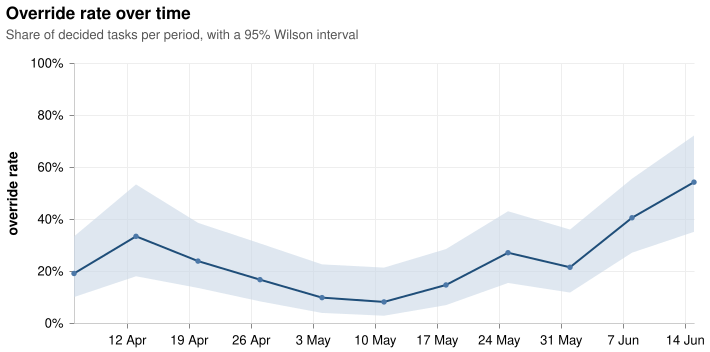

In [43]:
pictures["rate_over_time"]

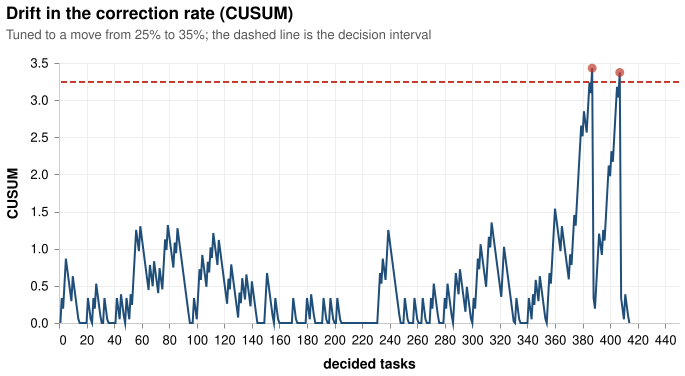

In [44]:
pictures["cusum"]

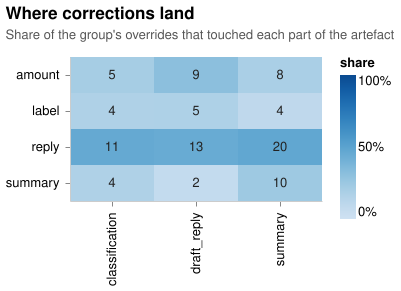

In [45]:
pictures["patch_heatmap"]

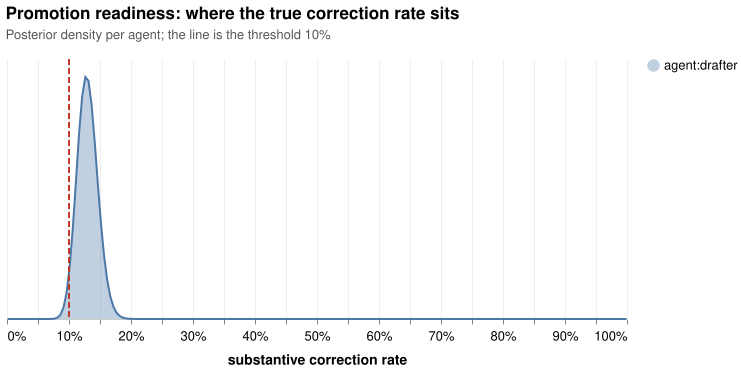

In [46]:
pictures["promotion"]

The reliability diagram needs an agent whose confidence means something. The
generator's `calibrated` outcome model draws acceptance from the confidence
the agent reported, so the curve should sit on the diagonal.

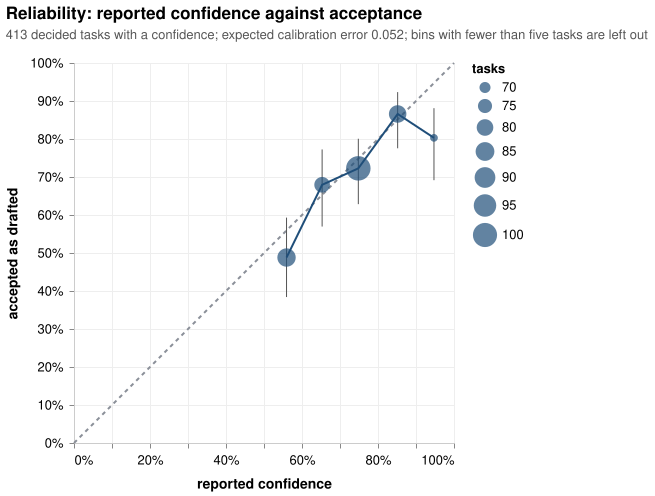

In [47]:
calibrated = frames(synthetic(11, tasks=420, days=70, outcome_model="calibrated", quorum_share=0.25))
charts.everything(calibrated)["reliability"]

## 12. The chain as a graph

The same chain reads as a typed graph: participants, tasks, review passes,
artefacts, decisions, whispers, deliberations and handoffs as nodes, and the
envelopes that join them as edges. Its vocabulary is fixed, and the diagram
is drawn from the declarations.

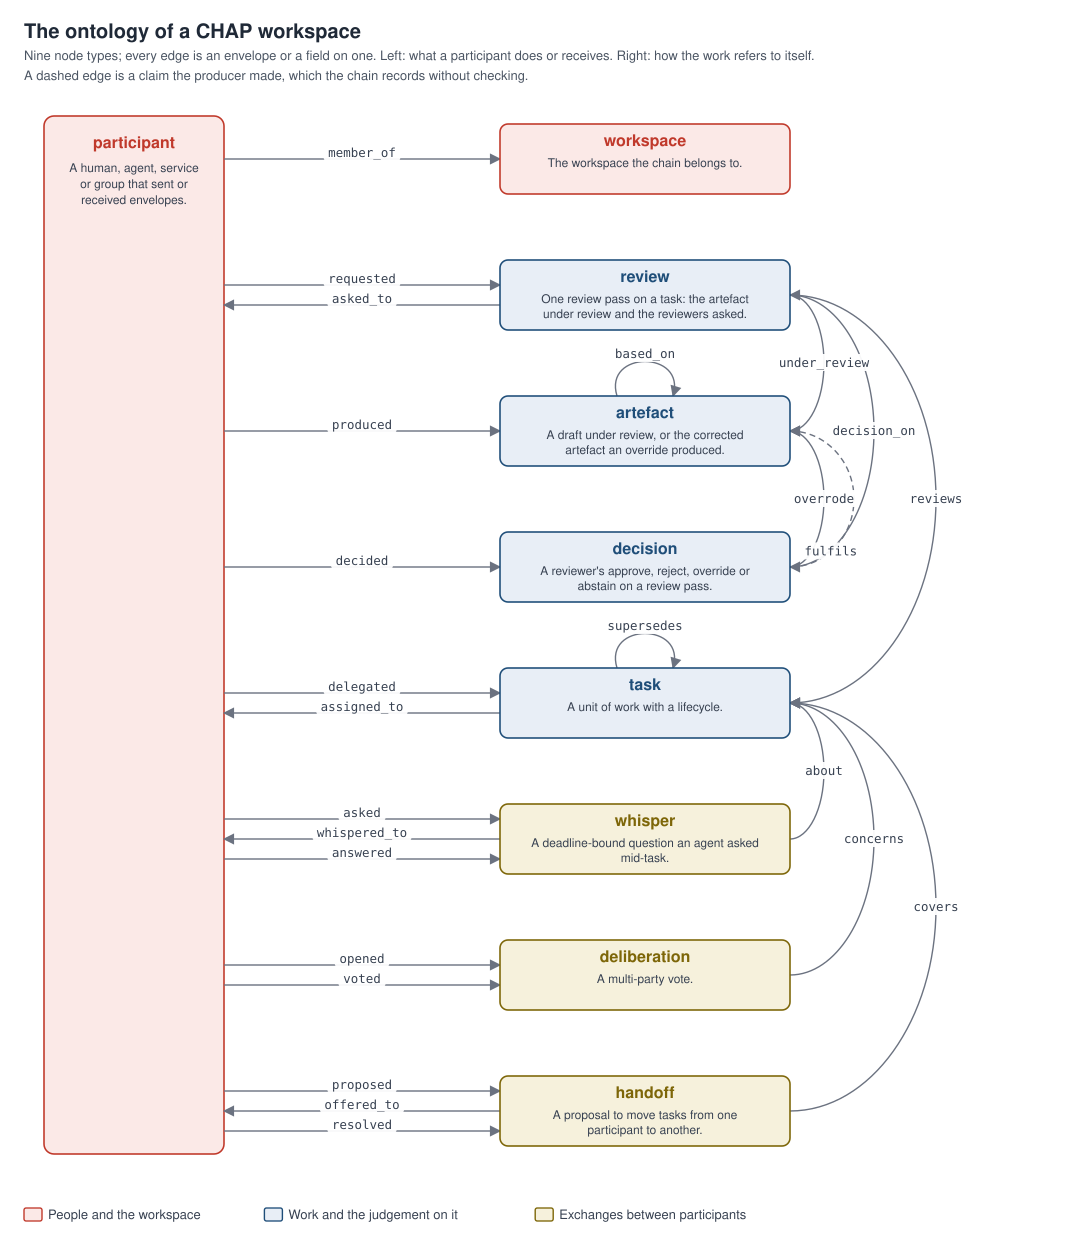

In [48]:
from chap_analytics import graph

graph.ontology_svg()

Two views come out of it. The lineage of one task is everything that led to
it, in time order, one lane per participant; the collaboration graph is the
people and agents of a workspace with the work that passed between them.

In [49]:
escalated = f.tasks[f.tasks["supersedes"].notna()]["task_id"].iloc[0]
graph.lineage_table(f, escalated)[["ts", "actor", "action", "node_type", "label"]]

,ts,actor,action,node_type,label
0,2026-03-05 18:09:26+00:00,service:intake,delegated,task,tsk_01M2ZN8PM2D3M5YPX0WRWBR7DY
1,2026-03-05 18:09:26+00:00,agent:drafter,assigned_to,task,tsk_01M2ZN8PM2D3M5YPX0WRWBR7DY
2,2026-03-05 18:10:31+00:00,agent:drafter,requested,review,review 0 of tsk_01M2ZN8PM2D3M5YPX0WRWBR7DY
3,2026-03-05 18:10:31+00:00,agent:drafter,produced,artefact,draft 0 of tsk_01M2ZN8PM2D3M5YPX0WRWBR7DY
4,2026-03-05 18:10:31+00:00,human:priya,asked_to,review,review 0 of tsk_01M2ZN8PM2D3M5YPX0WRWBR7DY
5,2026-03-05 18:30:31+00:00,human:sam,delegated,task,tsk_01M2ZN8PM3XYW3AHW4FK2WDHNV
6,2026-03-05 18:30:31+00:00,human:priya,assigned_to,task,tsk_01M2ZN8PM3XYW3AHW4FK2WDHNV


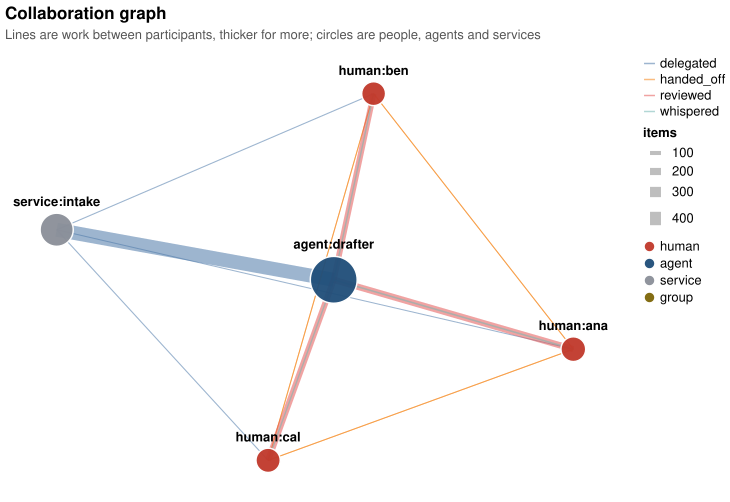

In [50]:
pictures["collaboration"]

In [51]:
graph.concentration(q)

,assignee,n_decisions,n_reviewers,top_reviewer,top_share,hhi,sufficient
0,agent:drafter,492,3,human:ana,0.351626,0.334003,True


In [52]:
cov = graph.coverage(q)
print(f"{cov.attrs['covered']} of {cov.attrs['shipped']} shipped outcomes had a person on the path")
graph.duties(q)

400 of 400 shipped outcomes had a person on the path


,check,subject,actor,detail


## 13. The report

`report.write` puts every decision into one HTML file: headline cards, a
filter bar, and a section per question with its charts and its brief. The
Vega runtime and the rows behind every chart are inside the file, so it
opens from a file share with no network, and each statistic is recomputed in
the browser as the reader filters, with a JavaScript mirror of the functions
above that the test suite checks against them.

In [53]:
from chap_analytics import report

path = report.write(q, os.path.join(out, "quarter.html"), title="Synthetic workspace, one quarter")
print(f"{os.path.getsize(path) / 1024:.0f} KB at {path}")

2489 KB at /sessions/happy-gallant-bohr/tmp/tmpnue_qhx0/quarter.html


## 14. Exports and models

`chap_analytics.export` writes the chain in the shapes other tools take: one
evaluation case per corrected task, the correction clusters most worth a
prompt revision, and the confidence threshold that reaches a target
acceptance. `chap_analytics.models` separates how strict a reviewer is from
how good the work was, and declines to fit below its minimum.

In [54]:
from chap_analytics import export, models

cases = export.evaluation_cases(f)
cases[["task_id", "kind", "reviewer", "intent_preserved", "rationale"]].head()

,task_id,kind,reviewer,intent_preserved,rationale
0,tsk_01M2ZN8PKW657FV2NZKNXG55WX,draft_reply,human:maya,True,Too curt for a customer who has waited a week.
1,tsk_01M2ZN8PKYAXP99CZYQ4CTGJ2P,draft_reply,human:sam,True,Too curt for a customer who has waited a week.
2,tsk_01M2ZN8PKZ03XYGRBN5PVGDYKE,draft_reply,human:maya,True,Too curt for a customer who has waited a week.
3,tsk_01M2ZN8PKZB56V09Q80MHACVYB,draft_reply,human:maya,False,Wrong carrier named.
4,tsk_01M2ZN8PM0P6YEAENA86QJRRPV,draft_reply,human:maya,True,Reads as a form letter. Name the order.


In [55]:
export.prompt_revision_candidates(q, top=5)[["task_kind", "top_path", "tag", "n", "reversing_share", "priority"]]

,task_kind,top_path,tag,n,reversing_share,priority
0,summary,reply,substance,8,1.0,16.0
1,summary,reply,tone,12,0.0,12.0
2,draft_reply,amount,substance,6,1.0,12.0
3,draft_reply,reply,substance,5,1.0,10.0
4,summary,summary,substance,5,1.0,10.0


In [56]:
export.routing_calibration(calibrated, target_acceptance=0.85)["threshold"]

In [57]:
m = models.reviewer_severity(q)
m[["unit", "role", "estimate", "se", "n", "accept_share"]] if m.attrs["fitted"] else m.attrs["reason"]

,unit,role,estimate,se,n,accept_share
0,agent:drafter,agent,0.000000,0.108181,492,0.778455
1,human:ana,reviewer,0.186159,0.172215,173,0.745665
2,human:ben,reviewer,0.034062,0.188719,155,0.774194
3,human:cal,reviewer,-0.220221,0.197444,164,0.817073


## Where next

The package README covers the loaders, the schema, the decision table and
the identity question in full, and the `docs` folder states each method's
assumptions and minimums:
https://github.com/BrightbeamAI/chap/tree/main/packages/chap-analytics

`chap_analytics.watch.Watcher` polls a live workspace, regenerates the report
and raises an alarm when the correction rate moves; the roadmap this package
follows is at
https://github.com/BrightbeamAI/chap/blob/main/ANALYTICS_ROADMAP.md